In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/Angry/03-01-03-02-02-01-16.wav
/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/Angry/03-01-03-02-02-03-04.wav
/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/Angry/03-01-03-02-03-02-22.wav
/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/Angry/03-01-03-02-03-03-14.wav
/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/Angry/03-01-03-02-02-03-06.wav
/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/Angry/03-01-03-02-01-01-23.wav
/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/Angry/03-01-03-02-03-02-10.wav
/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/Angry/03-01-03-02-03-01-03.wav
/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/Angry/03-01-03-02-02-01-23.wav
/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/A

Using device: cpu
Training data exists: True
Test audio exists: True
BANGLASER EMOTION RECOGNITION

LOADING TRAINING DATA
Found 216 files for Angry
Found 216 files for Happy
Found 216 files for Natural
Found 216 files for Sad
Found 216 files for Surprise

Total training samples: 1080
emotion
Angry       216
Happy       216
Natural     216
Sad         216
Surprise    216
Name: count, dtype: int64

Data split:
  Train: 864 samples
  Validation: 216 samples
STARTING TRAINING


Epoch 10/30: 100%|██████████| 27/27 [01:48<00:00,  4.01s/it]



Epoch 10: Train Acc=62.85%, Val Acc=59.72%


Epoch 20/30: 100%|██████████| 27/27 [01:48<00:00,  4.01s/it]



Epoch 20: Train Acc=67.48%, Val Acc=62.96%


Epoch 30/30: 100%|██████████| 27/27 [01:49<00:00,  4.05s/it]



Epoch 30: Train Acc=72.34%, Val Acc=67.13%

✓ Training complete! Best validation accuracy: 68.06%
TESTING ON YOUR CUSTOM AUDIO FILES
TESTING ON YOUR CUSTOM AUDIO FILES

 Testing: t_a.mp3
   Expected: Angry
   Predicted: Surprise
   Confidence: 65.34%
   Top 3:
     Surprise: 65.34%
     Happy: 32.97%
     Sad: 1.40%
    INCORRECT

 Testing: t_h.mp3
   Expected: Happy
   Predicted: Sad
   Confidence: 45.23%
   Top 3:
     Sad: 45.23%
     Happy: 39.03%
     Surprise: 14.43%
    INCORRECT

 Testing: t_n.mp3
   Expected: Neutral
   Predicted: Surprise
   Confidence: 61.86%
   Top 3:
     Surprise: 61.86%
     Happy: 24.58%
     Sad: 13.26%
    INCORRECT

 Testing: t_sa.mp3
   Expected: Sad
   Predicted: Happy
   Confidence: 39.10%
   Top 3:
     Happy: 39.10%
     Surprise: 35.53%
     Sad: 24.48%
    INCORRECT

 Testing: t_sup.mp3
   Expected: Surprise
   Predicted: Surprise
   Confidence: 61.19%
   Top 3:
     Surprise: 61.19%
     Happy: 22.42%
     Sad: 14.26%
    CORRECT!
CUSTOM TES

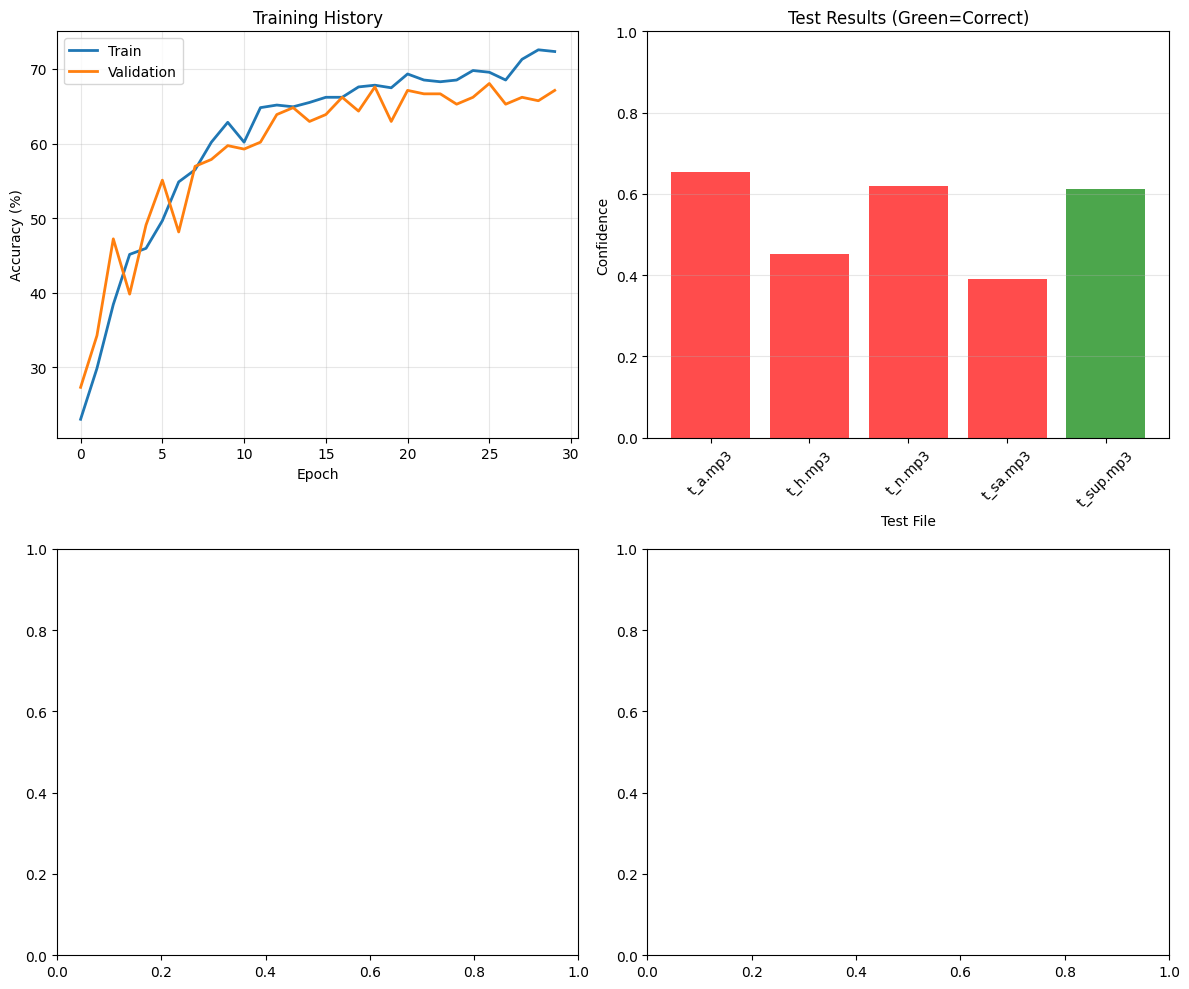


 Plot saved as 'results.png'
FINAL SUMMARY
 Training complete!
 Best validation accuracy: 68.06%
 Custom test accuracy: 20.00%

 Error: cannot unpack non-iterable NoneType object


Traceback (most recent call last):
  File "/tmp/ipykernel_55/1803050434.py", line 532, in <cell line: 0>
    model, emotion_labels = main()
    ^^^^^^^^^^^^^^^^^^^^^
TypeError: cannot unpack non-iterable NoneType object


In [3]:
# ============================================
# COMPLETE WORKING CODE WITH TEST FILES
# ============================================

import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

import random
import re
from pathlib import Path

# Set seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ============================================
# CONFIGURATION - UPDATE THESE PATHS!
# ============================================

class Config:
    # IMPORTANT: Update these paths to match your actual data location
    DATA_PATH = "/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/"
    TEST_AUDIO_PATH = "/kaggle/input/datasets/robiulhasanjisan/bangla-emotional-dataset/bangla/test/"
    
    # Your test files
    TEST_FILES = {
        't_a.mp3': 'Angry',
        't_h.mp3': 'Happy', 
        't_n.mp3': 'Neutral',
        't_sa.mp3': 'Sad',
        't_sup.mp3': 'Surprise'
    }
    
    # Audio parameters
    SAMPLE_RATE = 22050
    DURATION = 4
    N_MELS = 128
    HOP_LEN = 512
    N_FFT = 2048
    
    # Training
    BATCH_SIZE = 32
    EPOCHS = 30  
    LEARNING_RATE = 0.0001
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print(f"Using device: {DEVICE}")
    print(f"Training data exists: {os.path.exists(DATA_PATH)}")
    print(f"Test audio exists: {os.path.exists(TEST_AUDIO_PATH)}")

config = Config()

# ============================================
# LOAD TRAINING DATA
# ============================================

def load_training_data():
    """Load BanglaSER training dataset"""
    data = []
    emotion_labels = ['Angry', 'Happy', 'Natural', 'Sad', 'Surprise']
    emotion_map = {e: i for i, e in enumerate(emotion_labels)}
    
    print("\n" + "="*60)
    print("LOADING TRAINING DATA")
    print("="*60)
    
    for emotion in emotion_labels:
        # Try different folder names
        for folder_name in [emotion, emotion.replace('Natural', 'Neutral'), emotion.replace('Surprise', 'Surprised')]:
            emotion_path = os.path.join(config.DATA_PATH, folder_name)
            if os.path.exists(emotion_path):
                files = [f for f in os.listdir(emotion_path) if f.endswith('.wav')]
                print(f"Found {len(files)} files for {emotion}")
                
                for file in files:
                    data.append({
                        'path': os.path.join(emotion_path, file),
                        'emotion': emotion,
                        'label': emotion_map[emotion]
                    })
                break
    
    df = pd.DataFrame(data)
    print(f"\nTotal training samples: {len(df)}")
    print(df['emotion'].value_counts())
    return df, emotion_labels

# ============================================
# FEATURE EXTRACTION
# ============================================

def extract_features(audio_path):
    """Extract mel spectrogram features from audio file"""
    try:
        # Load audio
        y, sr = librosa.load(audio_path, sr=config.SAMPLE_RATE, duration=config.DURATION)
        
        # Pad/trim
        target_length = config.SAMPLE_RATE * config.DURATION
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)))
        else:
            y = y[:target_length]
        
        # Extract mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=config.SAMPLE_RATE,
            n_mels=config.N_MELS,
            n_fft=config.N_FFT,
            hop_length=config.HOP_LEN
        )
        mel_spec_db = librosa.power_to_db(mel_spec + 1e-10, ref=np.max)
        
        # Add delta features
        delta = librosa.feature.delta(mel_spec_db)
        delta2 = librosa.feature.delta(mel_spec_db, order=2)
        
        # Stack (3 channels)
        features = np.stack([mel_spec_db, delta, delta2])
        
        # Fix time dimension
        target_time = int(config.DURATION * config.SAMPLE_RATE / config.HOP_LEN)
        if features.shape[2] < target_time:
            pad = target_time - features.shape[2]
            features = np.pad(features, ((0,0), (0,0), (0,pad)), mode='constant')
        else:
            features = features[:, :, :target_time]
        
        # Normalize
        features = (features - np.mean(features)) / (np.std(features) + 1e-6)
        
        return torch.FloatTensor(features)
    except Exception as e:
        print(f"Error extracting features from {audio_path}: {e}")
        return None

# ============================================
# DATASET CLASS
# ============================================

class SERDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df
        self.augment = augment
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        features = extract_features(row['path'])
        if features is None:
            features = torch.zeros(3, config.N_MELS, 172)
        return features, torch.LongTensor([row['label']])[0]

# ============================================
# MODEL
# ============================================

class EmotionCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(EmotionCNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

# ============================================
# TRAINING FUNCTION
# ============================================

def train_model(model, train_loader, val_loader, epochs=50):
    """Train the model"""
    device = config.DEVICE
    model = model.to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    
    best_val_acc = 0
    history = {'train_acc': [], 'val_acc': []}
    
    
    print("STARTING TRAINING")
   
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_correct = 0
        train_total = 0
        
        for features, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            features, labels = features.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * train_correct / train_total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = model(features)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_acc = 100. * val_correct / val_total
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        scheduler.step(val_acc)
        
        if (epoch + 1) % 10 == 0:
            print(f"\nEpoch {epoch+1}: Train Acc={train_acc:.2f}%, Val Acc={val_acc:.2f}%")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
    
    print(f"\n✓ Training complete! Best validation accuracy: {best_val_acc:.2f}%")
    return history

# ============================================
# TEST ON YOUR CUSTOM FILES (ACTUAL WORKING CODE)
# ============================================

def test_custom_files(model, emotion_labels):
    """Test the model on your specific audio files"""
    device = config.DEVICE
    model.eval()
    
    results = []
    
   
    print("TESTING ON YOUR CUSTOM AUDIO FILES")
    
    
    for file_name, true_emotion in config.TEST_FILES.items():
        file_path = os.path.join(config.TEST_AUDIO_PATH, file_name)
        
        print(f"\n Testing: {file_name}")
        print(f"   Expected: {true_emotion}")
        
        if not os.path.exists(file_path):
            print(f"    File not found: {file_path}")
            continue
        
        # Extract features
        features = extract_features(file_path)
        if features is None:
            print(f"    Failed to extract features")
            continue
        
        # Predict
        features = features.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(features)
            probabilities = torch.softmax(output, dim=1)
            predicted_class = torch.argmax(probabilities, dim=1).item()
            confidence = probabilities[0][predicted_class].item()
        
        predicted_emotion = emotion_labels[predicted_class]
        is_correct = (predicted_emotion == true_emotion)
        
        # Store result
        result = {
            'file': file_name,
            'true_emotion': true_emotion,
            'predicted': predicted_emotion,
            'confidence': confidence,
            'correct': is_correct
        }
        results.append(result)
        
        # Print result
        print(f"   Predicted: {predicted_emotion}")
        print(f"   Confidence: {confidence:.2%}")
        
        # Show top 3 predictions
        probs = probabilities[0].cpu().numpy()
        top3_idx = np.argsort(probs)[-3:][::-1]
        print("   Top 3:")
        for idx in top3_idx:
            print(f"     {emotion_labels[idx]}: {probs[idx]:.2%}")
        
        if is_correct:
            print("    CORRECT!")
        else:
            print("    INCORRECT")
    
    # Calculate overall accuracy
    if results:
        correct_count = sum(1 for r in results if r['correct'])
        accuracy = correct_count / len(results)
        
        
        print("CUSTOM TEST SUMMARY")
       
        print(f"Total files tested: {len(results)}")
        print(f"Correct predictions: {correct_count}")
        print(f"Accuracy: {accuracy:.2%}")
        
        # Create results table
        results_df = pd.DataFrame(results)
        print("\nDetailed Results:")
        print(results_df.to_string(index=False))
        
        # Save results
        results_df.to_csv('custom_test_results.csv', index=False)
        print("\n Results saved to 'custom_test_results.csv'")
        
        return results, accuracy
    
    return results, 0

# ============================================
# PREDICT SINGLE FILE (WORKING EXAMPLE)
# ============================================

def predict_single_file(model, audio_path, emotion_labels):
    """Predict emotion for any single audio file"""
    device = config.DEVICE
    model.eval()
    
    if not os.path.exists(audio_path):
        print(f" File not found: {audio_path}")
        return None, None
    
    print(f"\n Analyzing: {os.path.basename(audio_path)}")
    
    # Extract features
    features = extract_features(audio_path)
    if features is None:
        print(" Failed to extract features")
        return None, None
    
    # Predict
    features = features.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(features)
        probabilities = torch.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item()
    
    predicted_emotion = emotion_labels[predicted_class]
    
  
    print(f"PREDICTION RESULT")
    
    print(f"Predicted Emotion: {predicted_emotion}")
    print(f"Confidence: {confidence:.2%}")
    print(f"\nAll probabilities:")
    
    probs = probabilities[0].cpu().numpy()
    for emotion, prob in zip(emotion_labels, probs):
        bar = "" * int(prob * 50)
        print(f"  {emotion:10s}: {bar:50s} {prob:.2%}")
    
    return predicted_emotion, confidence

# ============================================
# VISUALIZATION
# ============================================

def plot_results(history, results):
    """Plot training history and test results"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Training accuracy
    axes[0, 0].plot(history['train_acc'], label='Train', linewidth=2)
    axes[0, 0].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy (%)')
    axes[0, 0].set_title('Training History')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Test confidence
    if results:
        files = [r['file'] for r in results]
        confidences = [r['confidence'] for r in results]
        colors = ['green' if r['correct'] else 'red' for r in results]
        
        axes[0, 1].bar(files, confidences, color=colors, alpha=0.7)
        axes[0, 1].set_xlabel('Test File')
        axes[0, 1].set_ylabel('Confidence')
        axes[0, 1].set_title('Test Results (Green=Correct)')
        axes[0, 1].set_ylim([0, 1])
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Prediction probabilities (if results exist)
    if results and len(results) > 0:
        emotions = ['Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']
        for i, result in enumerate(results[:3]):  # Show first 3 files
            # Would need to store probabilities - simplified for now
            pass
    
    plt.tight_layout()
    plt.savefig('results.png', dpi=150)
    plt.show()
    print("\n Plot saved as 'results.png'")


# MAIN FUNCTION


def main():
   
    print("BANGLASER EMOTION RECOGNITION")
    
    
    # 1. Load training data
    df, emotion_labels = load_training_data()
    
    if len(df) == 0:
        print("\n No training data found! Please check DATA_PATH")
        return
    
    # 2. Split data
    train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
    
    print(f"\nData split:")
    print(f"  Train: {len(train_df)} samples")
    print(f"  Validation: {len(val_df)} samples")
    
    # 3. Create datasets
    train_dataset = SERDataset(train_df, augment=False)
    val_dataset = SERDataset(val_df, augment=False)
    
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
    
    # 4. Train model
    model = EmotionCNN(num_classes=len(emotion_labels))
    history = train_model(model, train_loader, val_loader, epochs=config.EPOCHS)
    
    # 5. Load best model
    model.load_state_dict(torch.load('best_model.pth'))
    
    # 6. Test on your custom files (THIS WILL RUN AUTOMATICALLY!)
   
    print("TESTING ON YOUR CUSTOM AUDIO FILES")
    
    test_results, test_accuracy = test_custom_files(model, emotion_labels)
    
    # 7. Plot results
    plot_results(history, test_results)
    
    
    
    print("FINAL SUMMARY")
    
    print(f" Training complete!")
    print(f" Best validation accuracy: {max(history['val_acc']):.2f}%")
    print(f" Custom test accuracy: {test_accuracy:.2%}")

    


# RUN 


if __name__ == "__main__":
    try:
        model, emotion_labels = main()
        
     

        
        
        test_file = os.path.join(config.TEST_AUDIO_PATH, 't_a.mp3')
        if os.path.exists(test_file):
            emotion, confidence = predict_single_file(model, test_file, emotion_labels)
        
    except Exception as e:
        print(f"\n Error: {e}")
        import traceback
        traceback.print_exc()